# Exercise 1

In [13]:
import numpy as np
import pandas as pd

    1.John owns a cake store that specializes in one product: their family recipe cheesecake. Let's import the chapter-exercise-data.csv source data file and store it as a DataFrame df.

In [6]:
df = pd.read_csv('chapter-exercise-data.csv')
df

,OrderID,PricePerItem,Quantity,ShippingDistance,CustomerID
0,1,27,5,3.0,1034
1,2,13,10,84.0,1009
2,3,52,1,NaN,1033
3,4,19,10,92.0,1018
4,5,25,3,2.0,1021
...,...,...,...,...,...
995,996,35,8,2.0,1030
996,997,5,9,43.0,1025
997,998,23,2,10.0,1006
998,999,22,9,49.0,1027


    2.John wants to see the value of each order, rather than the price and the quantity. Return the value for each row from the df.

In [7]:
df['PricePerItem']*df['Quantity']

0      135
1      130
2       52
3      190
4       75
      ... 
995    280
996     45
997     46
998    198
999    176
Length: 1000, dtype: int64

    3.John Realized that there might be null data in the DataFrame. Find the number of null values in the DataFrame for each column(s), if any.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           1000 non-null   int64  
 1   PricePerItem      1000 non-null   int64  
 2   Quantity          1000 non-null   int64  
 3   ShippingDistance  994 non-null    float64
 4   CustomerID        1000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


    4.John said that if he finds any null values in his data, he wanted to remove them as he believes these are errors in the database. Just to be cautious, he wants to make a seperate copy of the DataFrame without these errors. Create a separate DataFrame that displays only non-null rows.

In [10]:
df2 = df.dropna()
df2.info()

<class 'pandas.DataFrame'>
Index: 994 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           994 non-null    int64  
 1   PricePerItem      994 non-null    int64  
 2   Quantity          994 non-null    int64  
 3   ShippingDistance  994 non-null    float64
 4   CustomerID        994 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 46.6 KB


    5.John realized that the null values that he had found previously were actually legitimate orders, so he decided to go back and use the original DataFrame. He decided that the best way to fill it is with zero because he is goiung to deliver it himself. Fill in the null values in the DataFrame.

In [14]:
df = df.fillna(0)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           1000 non-null   int64  
 1   PricePerItem      1000 non-null   int64  
 2   Quantity          1000 non-null   int64  
 3   ShippingDistance  1000 non-null   float64
 4   CustomerID        1000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


# Exercise 2

In [30]:
import numpy as np
import pandas as pd

In [29]:
# Import .csv and create df
df = pd.read_csv('chapter-exercise-data.csv')

# Fill na values with zeros in df
df = df.fillna(0)

    1.John realized that he wanted to add the amount he would make per order onto his DataFrame. Create a new column that displays the amount he would make per order.

In [31]:
df['Amount'] = df['PricePerItem']*df['Quantity']
df

,OrderID,PricePerItem,Quantity,ShippingDistance,CustomerID,Amount
0,1,27,5,3.0,1034,135
1,2,13,10,84.0,1009,130
2,3,52,1,0.0,1033,52
3,4,19,10,92.0,1018,190
4,5,25,3,2.0,1021,75
...,...,...,...,...,...,...
995,996,35,8,2.0,1030,280
996,997,5,9,43.0,1025,45
997,998,23,2,10.0,1006,46
998,999,22,9,49.0,1027,198


    2.John wants to send out thank cards to the customers that spent at least $100 on their order. Filter the DataFrame for the list of customer IDs that fit this criteria.

In [32]:
df_100 = df[df['Amount'] >= 100]
df_100

,OrderID,PricePerItem,Quantity,ShippingDistance,CustomerID,Amount
0,1,27,5,3.0,1034,135
1,2,13,10,84.0,1009,130
3,4,19,10,92.0,1018,190
5,6,81,5,0.0,1041,405
7,8,44,8,65.0,1042,352
...,...,...,...,...,...,...
993,994,74,10,75.0,1020,740
994,995,41,8,69.0,1032,328
995,996,35,8,2.0,1030,280
998,999,22,9,49.0,1027,198


    3.John wants to send out a gift card for every 300th customer. Find the list of CustomerIDs that qualify for a gift card.

In [33]:
df.iloc[[299,599,899],4]

299    1040
599    1046
899    1044
Name: CustomerID, dtype: int64

    4.Find the average distance that an order travels when shipped.

In [35]:
float(df['ShippingDistance'].mean())

48.541

    5.John recently hired a courier that delivers all his orders for a flat fee, so he no longer needs to know the shipping distance. Drop the shipping distance column.

In [36]:
df = df.drop('ShippingDistance',axis=1)
df

,OrderID,PricePerItem,Quantity,CustomerID,Amount
0,1,27,5,1034,135
1,2,13,10,1009,130
2,3,52,1,1033,52
3,4,19,10,1018,190
4,5,25,3,1021,75
...,...,...,...,...,...
995,996,35,8,1030,280
996,997,5,9,1025,45
997,998,23,2,1006,46
998,999,22,9,1027,198


    6.John wants to know from his orders what is the most popular order quantity amount find the count of each order quantity.

In [39]:
df['Quantity'].mode()

df.groupby('Quantity')['OrderID'].count()

Quantity
1     113
2      95
3      98
4      94
5      98
6      91
7     103
8     102
9      96
10    110
Name: OrderID, dtype: int64

# Exercise 3

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Import .csv and create df
df = pd.read_csv('chapter-exercise-data.csv')

# Fill na values with zeros in df
df = df.fillna(0)

In [4]:
# Create the Amount column
df['Amount'] = df['PricePerItem']*df['Quantity']

# Create the df_100 DataFrame
df_100 = df[df['Amount'] >=100]

# Remove the Shipping Distance column
df = df.drop('ShippingDistance', axis=1)

# Create count_of_quantity series
Count_of_quantity = df.groupby('Quantity')['OrderID'].count()

    1.John wants to see the number of products contained in each order - the distribution of quantity. Create a histogram on the Quantity column from the df DataFrame.

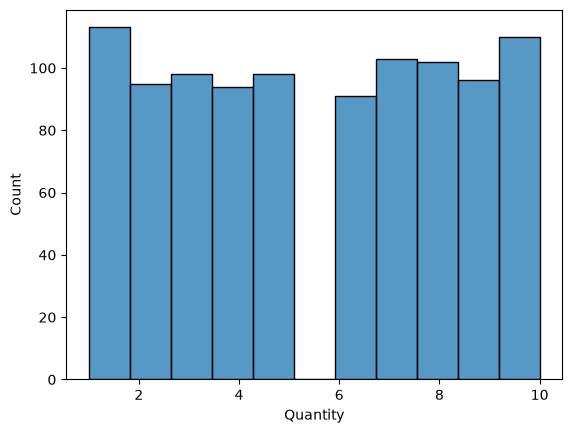

In [6]:
sns.histplot(df['Quantity']);

    2.John would like to know how many orders each customers has palced. Create a bar plot to show this-each bar should be the number of orders. aggregated by the count of customers who placed that many orders.

Text(0, 0.5, 'Num of Customers')

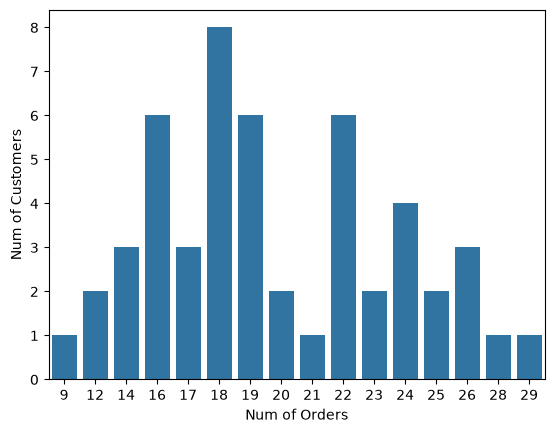

In [12]:
# Count number of OrderID for each CustomerID
cust_orders = pd.DataFrame(df.groupby('CustomerID')['OrderID'].count())

# Count number of Customers for each Order Quantity
orders_by_customers = pd.DataFrame(cust_orders.groupby('OrderID')['OrderID'].count())

# Create bar plot
sns.barplot(x=orders_by_customers.index, y='OrderID', data=orders_by_customers)
plt.xlabel('Num of Orders')
plt.ylabel('Num of Customers')

    3.John wants to know the relationship between the quantity of products in an order and the amount paid for that order. Create a scatter plot of Quantity vs Amount. 

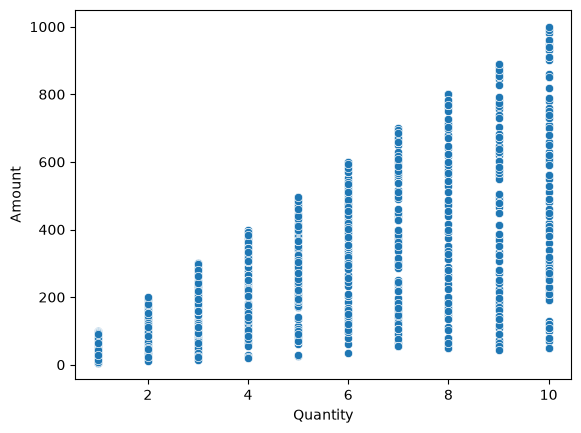

In [13]:
sns.scatterplot(x='Quantity',y='Amount', data=df);